# 02 — Preprocessing & Features

Read the labeled dataset, inspect the labeling breakdown and class balance, then engineer the V1 feature set. Feature logic lives in `src/features.py`; this notebook visualizes it.

**Leakage discipline:** TF-IDF vocabulary, imputer medians, and scaler stats are fit on the *training split only* (done in notebook 03 / `train.py`). Here we only inspect the deterministic, stateless row features. `number_of_labels_at_open` is deliberately excluded.

In [1]:
# --- Layout-agnostic bootstrap (see notebook 01 for the full rationale) -------
# Works from the dev repo (src/, data/processed/) or the submission folder
# (Source_Code/, Dataset/); every step is a no-op in the dev layout.
import os, sys, pathlib, shutil, importlib

def _bootstrap():
    here = pathlib.Path.cwd()
    root = pkg = None
    for d in [here, *here.parents]:
        for name in ('src', 'Source_Code'):
            if (d / name / 'config.py').exists():
                root, pkg = d, d / name
                break
        if root:
            break
    if root is None:
        raise RuntimeError('Could not find src/ or Source_Code/ from ' + str(here))
    os.environ['GHIC_PROJECT_ROOT'] = str(root)
    if not (root / 'config.yaml').exists() and (pkg / 'config.yaml').exists():
        shutil.copy(pkg / 'config.yaml', root / 'config.yaml')
    proc = root / 'data' / 'processed'
    proc.mkdir(parents=True, exist_ok=True)
    for fname in ('combined.csv', 'releases.json'):
        if not (proc / fname).exists() and (root / 'Dataset' / fname).exists():
            shutil.copy(root / 'Dataset' / fname, proc / fname)
    sys.path.insert(0, str(root if pkg.name == 'src' else pkg.parent))
    if pkg.name != 'src' and 'src' not in sys.modules:
        sys.modules['src'] = importlib.import_module(pkg.name)
    return root

_bootstrap()
# ------------------------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
from ghic.config import get_config
from ghic import features, utils
cfg = get_config(require_token=False)

2026-06-03 01:06:57,007 | INFO    | ghic.config | Loaded config: 3 repos, 7 bot logins, 7 bug labels, 12 non-actionable labels, 6 question labels (drop=True)


In [2]:
labeled = utils.DATA_PROCESSED / 'labeled.csv'
assert labeled.exists(), f'Missing {labeled}. Run notebook 01 or: python -m ghic.label'
df = pd.read_csv(labeled)
print(f'{len(df)} labeled issues across {df.repo_name.nunique()} repos')
df[['repo_name', 'number', 'title', 'label', 'label_rule']].head()

5885 labeled issues across 3 repos


,repo_name,number,title,label,label_rule
0,microsoft/vscode,209202,"""Sticky scroll"" is hard to discover and disable",0,R3b_state_not_planned
1,microsoft/vscode,209201,Mouse Cursor Remains Arrow Instead of I-Beam i...,0,R4_default_non_actionable
2,microsoft/vscode,209200,"idk im just reporting to help you guys, im new...",0,R3b_state_not_planned
3,microsoft/vscode,209199,The text inside the inline code is cut off.,0,R4_default_non_actionable
4,microsoft/vscode,209198,Copied folder can't be renamed,0,R3b_state_not_planned


## Class balance and which rule produced each label

In [3]:
print('Overall class balance:')
print(df.label.value_counts(normalize=True).rename({0: 'Non-Actionable', 1: 'Actionable Bug'}))
print('\nLabel rule breakdown:')
print(df.label_rule.value_counts())
print('\nPer-repo C1 ratio:')
print(df.groupby('repo_name').label.mean())

Overall class balance:
label
Non-Actionable    0.721835
Actionable Bug    0.278165
Name: proportion, dtype: float64

Label rule breakdown:
label_rule
R3b_state_not_planned              2102
R4_default_non_actionable          1834
R2_bug_label_completed              926
R1_merged_pr_link                   680
R3_non_actionable_label             312
R1b_merged_pr_textual_reference      31
Name: count, dtype: int64

Per-repo C1 ratio:
repo_name
facebook/react           0.181677
microsoft/vscode         0.214042
tensorflow/tensorflow    0.563652
Name: label, dtype: float64


## Engineer features (stateless layer)

In [4]:
# Pass release dates so days_since_last_release is included, matching what
# train.py uses (so this notebook reports the same 19 features as the model).
release_dates = train._load_release_dates() if 'train' in dir() else None
if release_dates is None:
    from ghic import train as _train
    release_dates = _train._load_release_dates()
feats = features.engineer_features(df, cfg, repo_release_dates=release_dates)
structured = features.structured_feature_columns(feats)
print(f'{len(structured)} structured features (+ TF-IDF text):')
print(structured)
feats[structured].describe().T

2026-06-03 01:07:09,988 | INFO    | ghic.train | Loaded release dates for 3 repos


19 structured features (+ TF-IDF text):
['title_len_chars', 'title_len_tokens', 'body_len_chars', 'body_len_tokens', 'has_code_block', 'has_link', 'has_image', 'repro_keyword_hits', 'has_repro_steps', 'author_account_age_days', 'author_public_repos', 'author_followers', 'author_is_first_time_contributor', 'created_hour_sin', 'created_hour_cos', 'created_dow_sin', 'created_dow_cos', 'opened_via_template', 'days_since_last_release']


,count,mean,std,min,25%,50%,75%,max
title_len_chars,5885.0,56.794732,34.187416,1.000000,35.000000,52.000000,72.000000,570.000000
title_len_tokens,5885.0,8.913849,5.531096,0.000000,5.000000,8.000000,11.000000,109.000000
body_len_chars,5885.0,2162.928292,3624.920786,0.000000,550.000000,1391.000000,2538.000000,62067.000000
body_len_tokens,5885.0,306.701784,496.270277,0.000000,85.000000,205.000000,361.000000,10626.000000
has_code_block,5885.0,0.505523,0.500012,0.000000,0.000000,1.000000,1.000000,1.000000
has_link,5885.0,0.602719,0.489377,0.000000,0.000000,1.000000,1.000000,1.000000
has_image,5885.0,0.227358,0.419161,0.000000,0.000000,0.000000,0.000000,1.000000
repro_keyword_hits,5885.0,0.722175,0.903272,0.000000,0.000000,0.000000,1.000000,5.000000
has_repro_steps,5885.0,0.485811,0.499841,0.000000,0.000000,0.000000,1.000000,1.000000
author_account_age_days,5866.0,2369.733208,1632.553599,0.000000,837.500000,2344.000000,3849.000000,6099.000000


## Do the features separate the classes? (a sanity check, not the model)

In [5]:
view = ['body_len_tokens', 'has_code_block', 'repro_keyword_hits', 'author_account_age_days', 'opened_via_template']
feats.assign(label=df.label.values).groupby('label')[view].mean().rename(index={0: 'Non-Actionable', 1: 'Actionable Bug'})

,body_len_tokens,has_code_block,repro_keyword_hits,author_account_age_days,opened_via_template
label,,,,,
Non-Actionable,298.242702,0.486347,0.704096,2179.375531,0.743173
Actionable Bug,328.653024,0.555284,0.769090,2863.590074,0.615150


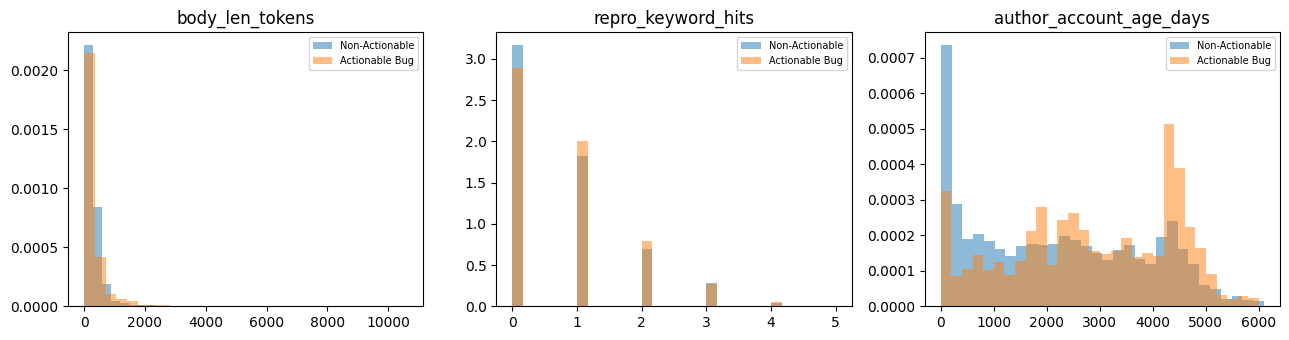

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col in zip(axes, ['body_len_tokens', 'repro_keyword_hits', 'author_account_age_days']):
    for lbl, name in [(0, 'Non-Actionable'), (1, 'Actionable Bug')]:
        ax.hist(feats[col][df.label.values == lbl].dropna(), bins=30, alpha=0.5, label=name, density=True)
    ax.set_title(col); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()